# Sandpile stabilization visualization

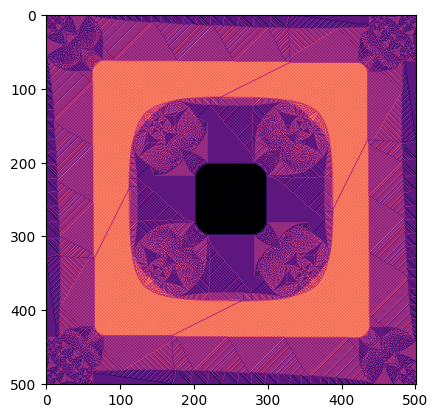

number of frames: 2459


In [36]:
import zarr
import matplotlib.pyplot as plt
import numpy as np

data = zarr.open('../sandpile_data/group_id_data/data.zarr', mode='r')
last_frame = data['history'][500] # Grabs the last saved state

plt.imshow(last_frame, cmap='magma')
plt.show()
print('number of frames:', len(data['history']))

In [113]:
def smooth_frame(frame):
    # Vectorized smoothing: replaces unstable pixels (>3) with neighbor if all neighbors equal
    # Extract the interior region (excluding borders) and neighbors
    interior = frame[1:-1, 1:-1]
    above = frame[0:-2, 1:-1]
    left = frame[1:-1, 0:-2]
    right = frame[1:-1, 2:]

    # Create a mask for pixels > 3 where all neighbors are equal
    mask = (interior > 3) & (above == left) & (above == right)

    # Update the frame in place
    frame[1:-1, 1:-1][mask] = above[mask]

f_chunc = last_frame[200-5:200+5,100-5:100+5].copy()
print(f_chunc)
fc_smooth = smooth_frame(f_chunc)
print(f_chunc)

[[7 3 7 3 7 3 7 3 7 3]
 [3 7 3 7 3 7 3 7 3 7]
 [7 3 7 3 7 3 7 3 7 3]
 [3 7 3 7 3 7 3 7 3 7]
 [7 3 7 3 7 3 7 3 7 3]
 [3 7 3 7 3 7 3 7 3 7]
 [7 3 7 3 7 3 7 3 7 3]
 [3 7 3 7 3 7 3 7 3 7]
 [7 3 7 3 7 3 7 3 7 3]
 [3 7 3 7 3 7 3 7 3 7]]
[[7 3 7 3 7 3 7 3 7 3]
 [3 3 3 3 3 3 3 3 3 7]
 [7 3 3 3 3 3 3 3 3 3]
 [3 3 3 3 3 3 3 3 3 7]
 [7 3 3 3 3 3 3 3 3 3]
 [3 3 3 3 3 3 3 3 3 7]
 [7 3 3 3 3 3 3 3 3 3]
 [3 3 3 3 3 3 3 3 3 7]
 [7 3 3 3 3 3 3 3 3 3]
 [3 7 3 7 3 7 3 7 3 7]]


In [ ]:
import cv2
import os

smoothing = False

# Create a custom color mapping function
def custom_colormap(frame):
    """Map pixel values to colors"""
    height, width = frame.shape
    colored_frame = np.zeros((height, width, 3), dtype=np.uint8)

    # Define colors in BGR format (OpenCV uses BGR, not RGB)
    # colors = {
    #     0: (25, 25, 25),        # Black
    #     1: (204, 153, 0),      # Blue
    #     2: (25, 204, 230),      # Green
    #     3: (0, 0, 255),      # Red
        # 11: (204//2, 153//2, 0),      # Blue
        # 12: (0, 204//2, 230//2),      # Green
        # 13: (0, 0, 255//2),      # Red

    colors = {
        0: (25, 25, 25),        # Black
        1: (255, 253, 0),       # Cyan
        2: (0, 254, 255),       # Yellow
        3: (0, 0, 255),         # Red
        # 4: (0, 0, 255),         # Red
        5: (0, 0, 0),           # Black
    }
    # for i in range(4,20):
    #     colors[i] = (50, 50, 50)

    # Apply the custom colormap for specified values
    for value, color in colors.items():
        mask = frame == value
        colored_frame[mask] = color

    # All other values are treated as 0 (black)
    # colored_frame is already initialized as all zeros, so no additional processing needed

    return colored_frame

# Load data and create video with custom colormap
data = zarr.open('../sandpile_data/group_id_data/data.zarr', mode='r')
history = data['history']

print(f"Creating video from {len(history)} frames with custom colormap...")
print(f"Frame shape: {history[0].shape}")

# Get frame dimensions
frame_height, frame_width = history[0].shape
fps = 30  # frames per second

# Define video output path
output_path = '../sandpile_data/group_id_data/sandpile_visualization.avi'
if smoothing:
    output_path = '../sandpile_data/group_id_data/sandpile_visualization_smoothed.avi'

# Initialize VideoWriter with MJPEG codec (lossless)
fourcc = cv2.VideoWriter_fourcc(*'MJPG')
out = cv2.VideoWriter(output_path, fourcc, fps,
                       (frame_width, frame_height))

# Process each frame
for idx, frame in enumerate(history):
    if smoothing:
        smooth_frame(frame)
    if idx % 200 == 0:
        print(f"Processing frame {idx}/{len(history)}")

    # Apply custom colormap directly to raw frame values
    colored_frame = custom_colormap(frame)

    # Flip frame horizontally (left/right)
    colored_frame = cv2.flip(colored_frame, 1)

    # Write frame to video
    out.write(colored_frame)

# Release the video writer
out.release()
print(f"Video saved to: {os.path.abspath(output_path)}")


Creating video from 1630 frames with custom colormap...
Frame shape: (455, 455)
Processing frame 0/1630
Processing frame 200/1630
Processing frame 400/1630
Processing frame 600/1630
Processing frame 800/1630
Processing frame 1000/1630
Processing frame 1200/1630
Processing frame 1400/1630
Processing frame 1600/1630
Video saved to: /Users/alan/Python/sandpile_data/group_id_data/sandpile_visualization.avi


In [ ]:
# import cv2
# import os

# # Load data
# data = zarr.open('group_id_data/data.zarr', mode='r')
# history = data['history']

# print(f"Creating video from {len(history)} frames...")
# print(f"Frame shape: {history[0].shape}")

# # Get frame dimensions
# frame_height, frame_width = history[0].shape
# fps = 30  # frames per second

# # Define video output path
# output_path = 'group_id_data/sandpile_cool.mp4'

# # Initialize VideoWriter
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Use mp4v codec
# out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

# # Find min and max for normalization (using first few frames for efficiency)
# sample_frames = min(50, len(history))
# all_values = np.concatenate([history[i].flatten() for i in range(sample_frames)])
# vmin, vmax = np.percentile(all_values, [2, 98])

# print(f"Value range for normalization: {vmin:.2f} to {vmax:.2f}")

# # Process each frame
# for idx, frame in enumerate(history):
#     smooth_frame(frame)  # Apply smoothing to the frame
#     if idx % 50 == 0:
#         print(f"Processing frame {idx}/{len(history)}")

#     # Normalize frame to 0-255 range
#     normalized = np.clip((frame - vmin) / (vmax - vmin) * 255, 0, 255).astype(np.uint8)

#     # Apply colormap (magma) for better visualization
#     colored_frame = cv2.applyColorMap(normalized, cv2.COLORMAP_JET)

#     # Write frame to video
#     out.write(colored_frame)

# # Release the video writer
# out.release()
# print(f"Video saved to: {os.path.abspath(output_path)}")


Creating video from 2030 frames...
Frame shape: (501, 501)
Value range for normalization: 0.00 to 7.00
Processing frame 0/2030
Processing frame 50/2030
Processing frame 100/2030
Processing frame 150/2030
Processing frame 200/2030
Processing frame 250/2030
Processing frame 300/2030
Processing frame 350/2030
Processing frame 400/2030
Processing frame 450/2030
Processing frame 500/2030
Processing frame 550/2030
Processing frame 600/2030
Processing frame 650/2030
Processing frame 700/2030
Processing frame 750/2030
Processing frame 800/2030
Processing frame 850/2030
Processing frame 900/2030
Processing frame 950/2030
Processing frame 1000/2030
Processing frame 1050/2030
Processing frame 1100/2030
Processing frame 1150/2030
Processing frame 1200/2030
Processing frame 1250/2030
Processing frame 1300/2030
Processing frame 1350/2030
Processing frame 1400/2030
Processing frame 1450/2030
Processing frame 1500/2030
Processing frame 1550/2030
Processing frame 1600/2030
Processing frame 1650/2030
Pr

# Load image

In [34]:
import sandpile_utils.utils as su
import importlib
importlib.reload(su)
dir(su)

lennarr = su.load_as_grayscale("/Users/alan/Python/sandpile_data/group_id_data/lenna.png")

Loaded grayscale image: (512, 512)


np.float64(12.25)

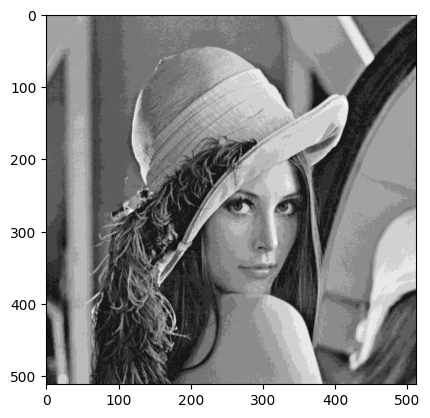

In [ ]:
plt.imshow(np.round(lennarr / 20), cmap='gray')
np.max(lennarr / 20)

# Stabilization test
/ discard

In [2]:
# Stabilization equality test
import taichi as ti
import numpy as np
import sandpile_utils.utils as su

import importlib
importlib.reload(su)

ti.init(arch=ti.gpu)

N = 50
# Fields for Version A
grid_a = ti.field(dtype=ti.i32, shape=(N, N))
next_a = ti.field(dtype=ti.i32, shape=(N, N))

# Fields for Version B
grid_b = ti.field(dtype=ti.i32, shape=(N, N))
next_b = ti.field(dtype=ti.i32, shape=(N, N))

# Scalars to track if toppling happened
was_modified_a = ti.field(dtype=ti.i32, shape=())
was_modified_b = ti.field(dtype=ti.i32, shape=())

@ti.kernel
def initialize_grids():
    for i, j in grid_a:
        # Start with a random high-energy state (0 to 10 grains)
        val = ti.random(int) % 11
        grid_a[i, j] = val
        grid_b[i, j] = val

topple_a = su.topple
topple_b = su.topple_multi

@ti.kernel
def check_equality() -> bool:
    equal = True
    for i, j in grid_a:
        if grid_a[i, j] != grid_b[i, j]:
            equal = False
    return equal

# --- Execution ---
initialize_grids()

# Stabilize A
print("Stabilizing Grid A...")
while True:
    topple_a(grid_a, next_a, was_modified_a)
    if was_modified_a[None] == 0:
        break

# # Stabilize B
# print("Stabilizing Grid B...")
# while True:
#     topple_b(grid_b, next_b, was_modified_b)
#     if was_modified_b[None] == 0:
#         break

# Specialized topple with pointer swap
print("Stabilizing Grid B with pointer swap...")
while True:
    next_b.fill(0)
    su.topple_kernel(grid_b, next_b, was_modified_b)
    grid_b, next_b = next_b, grid_b  # Swap pointers
    if was_modified_b[None] == 0:
        break

# Comparison
if check_equality():
    print("SUCCESS: Both implementations reached the same stable state.")
else:
    print("FAILURE: The stable states differ!")

[Taichi] Starting on arch=metal
Stabilizing Grid A...
Stabilizing Grid B with pointer swap...
SUCCESS: Both implementations reached the same stable state.
